In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import fetch_openml

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# --- 1. Load Data ---
print("Loading 'car' dataset from OpenML... (This may take a moment)")
X, y = fetch_openml(
    name="car",
    version=1,
    as_frame=True,
    return_X_y=True
)

df = X.copy()
df["class"] = y

print("Data loaded successfully.")
print("First 5 rows:")
display(df.head())

Loading 'car' dataset from OpenML... (This may take a moment)
Data loaded successfully.
First 5 rows:


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
# --- 2. Data Preprocessing ---

# A. Encode Categorical Features
# Manual mapping as defined in the problem statement
df["buying"]   = df["buying"].map({"low":0, "med":1, "high":2, "vhigh":3})
df["maint"]    = df["maint"].map({"low":0, "med":1, "high":2, "vhigh":3})
df["doors"]    = df["doors"].map({"2":2, "3":3, "4":4, "5more":5})
df["persons"]  = df["persons"].map({"2":2, "4":4, "more":5})
df["lug_boot"] = df["lug_boot"].map({"small":0, "med":1, "big":2})
df["safety"]   = df["safety"].map({"low":0, "med":1, "high":2})

# B. Encode Target
df["target"] = df["class"].map({
    "unacc": 0,
    "acc": 1,
    "good": 2,
    "vgood": 3
})

# Define features
feature_names = ["buying","maint","doors","persons","lug_boot","safety"]

# C. Separate Features and Target
X = df[feature_names]
y = df["target"]

# D. Imputation (Handling Missing Values)
imputer = SimpleImputer(strategy="most_frequent")
imputer.set_output(transform="pandas")
X_imputed = imputer.fit_transform(X)

# E. Scaling (Standardization)
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_scaled = scaler.fit_transform(X_imputed)

# F. Split Data
X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Data processed. Training shape: {X_tr.shape}, Test shape: {X_te.shape}")

Data processed. Training shape: (1296, 6), Test shape: (432, 6)


In [4]:
# --- 3. Prediction Helper Function ---

def predict_sample(model, raw_sample_list, imputer, scaler, feature_names, class_labels):
    """
    Takes a raw sample list, encoded appropriately, imputes, scales, and predicts.
    Note: The input raw_sample_list here is expected to be already manually encoded 
    (integers) as per the user's snippet logic, OR we could map them here.
    Given the user snippet manually maps them before creating the list/array, 
    we'll assume the inputs are pre-mapped integers or map them if they are strings.
    """
    # Mappings for reference
    maps = {
        0: {"low":0, "med":1, "high":2, "vhigh":3},
        1: {"low":0, "med":1, "high":2, "vhigh":3},
        2: {"2":2, "3":3, "4":4, "5more":5},
        3: {"2":2, "4":4, "more":5},
        4: {"small":0, "med":1, "big":2},
        5: {"low":0, "med":1, "high":2}
    }
    
    processed_sample = []
    for i, val in enumerate(raw_sample_list):
        if isinstance(val, str) and i in maps:
             processed_sample.append(maps[i][val])
        else:
             processed_sample.append(val)
             
    sample_df = pd.DataFrame([processed_sample], columns=feature_names)
            
    # Impute
    sample_imp = imputer.transform(sample_df)
    
    # Scale
    sample_scaled = scaler.transform(sample_imp)
    
    # Predict
    pred_idx = model.predict(sample_scaled)[0]
    pred_label = class_labels[pred_idx]
    
    print(f"Sample Prediction ({model.__class__.__name__}): {pred_label}")
    return pred_label

# Define sample data (from user request)
# buying, maint, doors, persons, lug_boot, safety
raw_sample_data = ["vhigh", "high", "4", "more", "big", "high"]
target_labels = {0:"Unacceptable", 1:"Acceptable", 2:"Good", 3:"Very Good"}

print("Sample data defined.")

Sample data defined.


Gaussian Naive Bayes Performance:
Accuracy: 0.7523
------------------------------
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       303
           1       0.53      0.34      0.42        96
           2       0.00      0.00      0.00        17
           3       0.25      1.00      0.41        16

    accuracy                           0.75       432
   macro avg       0.42      0.56      0.43       432
weighted avg       0.76      0.75      0.75       432



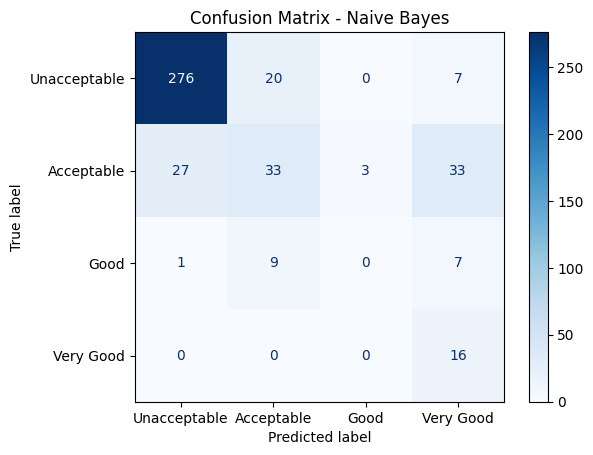

Sample Prediction (GaussianNB): Acceptable


'Acceptable'

In [5]:
# --- 4. Model: Gaussian Naive Bayes ---

# Initialize
gnb = GaussianNB()

# Train
gnb.fit(X_tr, y_tr)

# Predict
y_pred_gnb = gnb.predict(X_te)

# Evaluate
print("Gaussian Naive Bayes Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_gnb):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_gnb))

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred_gnb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_labels.values())
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

# Sample Prediction
predict_sample(gnb, raw_sample_data, imputer, scaler, feature_names, target_labels)

Decision Tree Performance:
Accuracy: 0.9676
------------------------------
              precision    recall  f1-score   support

Unacceptable       0.98      0.99      0.98       303
  Acceptable       0.93      0.93      0.93        96
        Good       0.94      0.88      0.91        17
   Very Good       1.00      0.94      0.97        16

    accuracy                           0.97       432
   macro avg       0.96      0.93      0.95       432
weighted avg       0.97      0.97      0.97       432



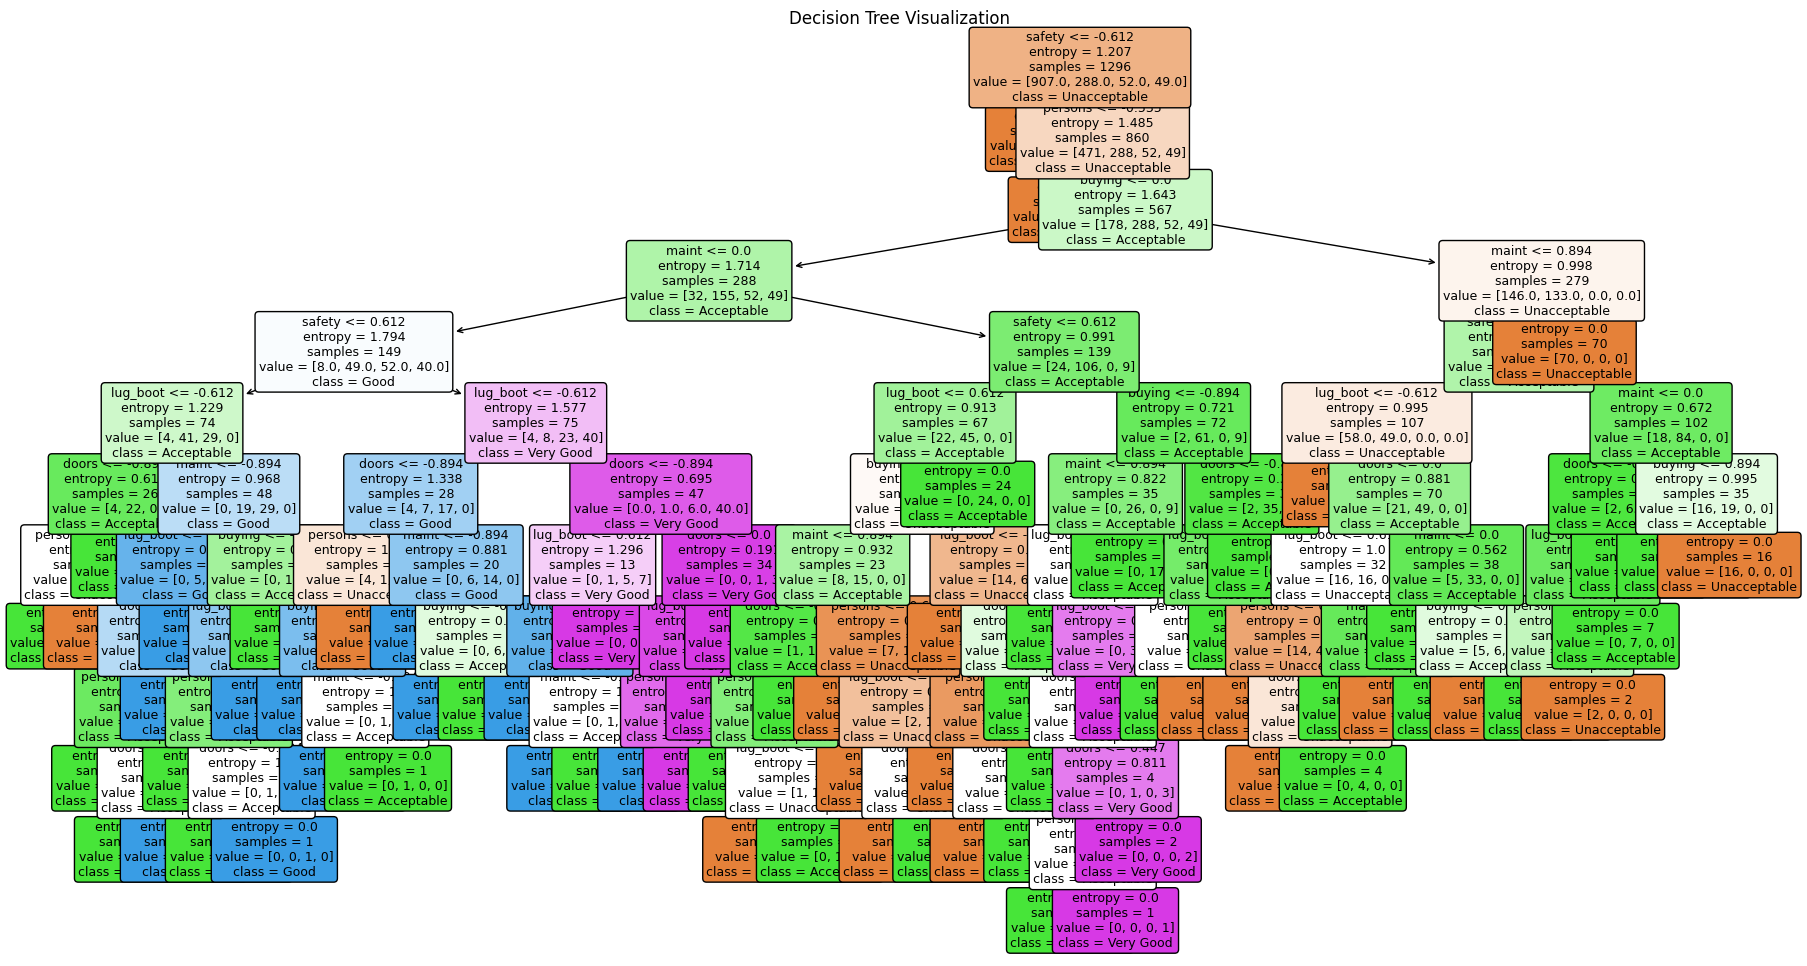

Sample Prediction (DecisionTreeClassifier): Unacceptable


'Unacceptable'

In [6]:
# --- 5. Model: Decision Tree ---

# Initialize
dt = DecisionTreeClassifier(criterion="entropy", random_state=0, max_depth=None, min_samples_leaf=1)

# Train
dt.fit(X_tr, y_tr)

# Predict
y_pred_dt = dt.predict(X_te)

# Evaluate
print("Decision Tree Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_dt):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_dt, target_names=list(target_labels.values())))

# Visualization
plt.figure(figsize=(22, 12))
plot_tree(
    dt,
    feature_names=feature_names,
    class_names=list(target_labels.values()),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Visualization")
plt.show()

# Sample Prediction
predict_sample(dt, raw_sample_data, imputer, scaler, feature_names, target_labels)

In [7]:
# --- 6. Model: MLP Classifier ---

# Initialize
mlp = MLPClassifier(hidden_layer_sizes=(20, 10), activation='relu', max_iter=1000, random_state=42)

# Train
mlp.fit(X_tr, y_tr)

# Predict
y_pred_mlp = mlp.predict(X_te)

# Evaluate
print("MLP Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_te, y_pred_mlp):.4f}")
print("-" * 30)
print(classification_report(y_te, y_pred_mlp, target_names=list(target_labels.values())))

# Sample Prediction
predict_sample(mlp, raw_sample_data, imputer, scaler, feature_names, target_labels)

MLP Classifier Performance:
Accuracy: 0.9884
------------------------------
              precision    recall  f1-score   support

Unacceptable       1.00      0.99      1.00       303
  Acceptable       0.97      0.99      0.98        96
        Good       1.00      0.88      0.94        17
   Very Good       0.94      1.00      0.97        16

    accuracy                           0.99       432
   macro avg       0.98      0.97      0.97       432
weighted avg       0.99      0.99      0.99       432

Sample Prediction (MLPClassifier): Unacceptable


'Unacceptable'

Final Comparison:
            Model  Accuracy
0     Naive Bayes  0.752315
1   Decision Tree  0.967593
2  MLP Classifier  0.988426


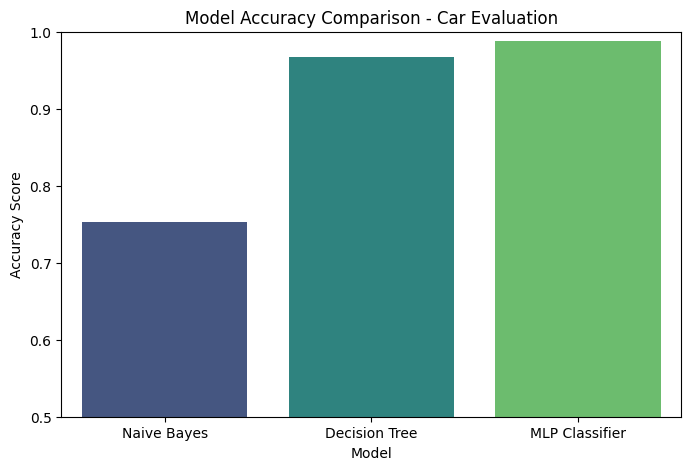

In [8]:
# --- 7. Model Comparison ---

results = pd.DataFrame({
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP Classifier'],
    'Accuracy': [
        accuracy_score(y_te, y_pred_gnb),
        accuracy_score(y_te, y_pred_dt),
        accuracy_score(y_te, y_pred_mlp)
    ]
})

print("Final Comparison:")
print(results)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='viridis', hue='Model', legend=False)
plt.title("Model Accuracy Comparison - Car Evaluation")
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy Score")
plt.show()